In [1]:
import numpy as np
# from PIL import Image
import taichi as ti
import taichi_volume_renderer as tvr
from scipy.ndimage import zoom
import matplotlib.pyplot as plt
from utils import run_optimization_3d, resample_polyline, get_volume, quaternion_to_rotation_matrix, rotation_matrix_to_quaternion

ti.init(arch=ti.gpu)

[Taichi] version 1.7.3, llvm 15.0.1, commit 5ec301be, win, python 3.12.3
[Taichi] Starting on arch=cuda


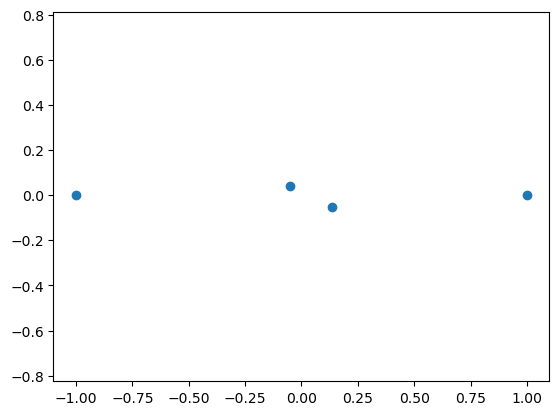

In [100]:
def init_trajectory(control_point_num):  # 生成初始轨迹
    upsampled_trajectory = resample_polyline([
        [-1, 0, 0, 0.5 ** 0.5, 0, 0, -0.5 ** 0.5, 0],
        [0, 0, 0, 0.5 ** 0.5, 0, 0, -0.5 ** 0.5, 0],
        [0, 0, 0, 0.5 ** 0.5, 0, 0, 0.5 ** 0.5, 1],  # 最后一个维度只是为了人为控制不同段地速度
        [1, 0, 0, 0.5 ** 0.5, 0, 0, 0.5 ** 0.5, 1]
    ], control_point_num)
    upsampled_trajectory[1:-1] += np.random.randn(control_point_num - 2, upsampled_trajectory.shape[1]) * 0.1  # 添加噪声
    xs = upsampled_trajectory[:, 0]
    ys = upsampled_trajectory[:, 1]
    zs = upsampled_trajectory[:, 2]
    rotations = upsampled_trajectory[:, 3:7]  # 四元数数组
    rotations /= np.linalg.norm(rotations, axis=1, keepdims=True)  # 归一化
    return xs, ys, zs, rotations

sofa_w = 1  # 求解域的尺寸
sofa_h = 1
sofa_d = 1

xs, ys, zs, rotations = init_trajectory(  # 初始轨迹
    control_point_num=4  # 轨迹的控制点数量 16 5 6
)

plt.scatter(xs, ys)
plt.axis('equal')
plt.show()

In [3]:
# 定义哪里是墙

from utils import test_forbidden_function_3d

@ti.func
def is_forbidden(x0, y0, z0, x1, y1, z1):  # 指定哪里是墙
    return ((x0 > 0.) ^ (x1 > 0.)) and (((y1 > 0.) ^ (z1 > 0.)) or abs(y1) > 0.5 or abs(z1) > 0.5)  # 两个正方形的孔

image = test_forbidden_function_3d(is_forbidden, -1, 1, -1, 1, -1, 1, 64, wall_normal=[0.1, 0, 0])
# tvr.plot_volume(image, init_taichi=False)

In [263]:
trajectory = np.load('../trajectory/穿过两个正方形孔_13/sofa_600.npy')
# trajectory = np.load('../trajectory/穿过两个正方形孔_13/sofa_100_before_changing_final_rotation.npy')
xs = trajectory[:, 0]
ys = trajectory[:, 1]
zs = trajectory[:, 2]
rotations = trajectory[:, 3:]

len(xs)

14

In [ ]:
rotations[0] = [0.5 ** 0.5, 0, 0, -0.5 ** 0.5]  # 第一个旋转改为-90度，绕z轴旋转
rotations[-1] = [0.5 ** 0.5, 0, 0, 0.5 ** 0.5]  # 最后一个旋转改为90度，绕z轴旋转

In [4]:
# 对称化函数

def symmetrize_list(array):  # 识别对称性，自动将一个用列表表示的函数改造成奇函数或偶函数。支持任意维的数组，只有第一个轴被视为因变量变化的方向
    symmetrized_array_0 = (array + array[::-1]) * 0.5  # 偶函数化
    symmetrized_array_1 = (array - array[::-1]) * 0.5  # 奇函数化
    if np.sum((symmetrized_array_0 - array) ** 2) < np.sum((symmetrized_array_1 - array) ** 2):  # 更接近偶函数
        return symmetrized_array_0
    else:  # 更接近奇函数
        return symmetrized_array_1

def symmetrize(xs, ys, zs, rotations):  # 对称化，其中的对称性是人为指定的。注意指定对称性可能会导致搜索不到真正的最优解
    xs = symmetrize_list(xs)
    ys = symmetrize_list(ys)
    zs = symmetrize_list(zs)
    for i in range(4):
        rotations[:, i] = symmetrize_list(rotations[:, i])

    # 增加轨迹的对称性，其合理性是从数值结果中观察出来的
    ys = (ys - zs) * 0.5
    zs = -ys
    # rotations[:, 2] = (rotations[:, 2] - rotations[::-1, 3]) * 0.5
    # rotations[:, 3] = -rotations[::-1, 2]

    rotations /= np.linalg.norm(rotations, axis=1, keepdims=True)  # 归一化

    return xs, ys, zs, rotations

In [131]:
best_score, xs, ys, zs, rotations, rotation_matrices, sofa, maximal_volume_record = run_optimization_3d(
    is_forbidden,
    # 一开始解除注释这三个
    # xs,
    # ys,
    # zs,
    # rotations,
    
    # 精炼结果时解除注释这三个
    zoom(xs, zoom=2, order=1),  # 上采样以获得更精确的轨道
    zoom(ys, zoom=2, order=1),  # 上采样以获得更精确的轨道
    zoom(zs, zoom=2, order=1),  # 上采样以获得更精确的轨道
    zoom(rotations, zoom=(2, 1), order=1),  # 上采样以获得更精确的轨道

    sofa_w=sofa_w,
    sofa_h=sofa_h,
    mutation_sigma_pos=0.1,  # 变异率
    mutation_sigma_rotation=0.1,  # 变异率
    symmetrize_function=symmetrize,
    iterations=10000,  # 200000
    trajectory_upsampling=73,  # 41 101 73
    regularization=0.02,  # 正则化 0.02
    regularization_mode='L2',  # 正则化模式，可以是'L1'或'L2'
    resolution=80,  # 64 80
    print_every=500,  # 1000 500
    save_image_every=100,
    save_image_path='../images/穿过两个正方形孔_18/sofa_',
    save_image_start_id=900,  # 文件起始编号，精炼结果时需要设置
    save_trajectory_path='../trajectory/穿过两个正方形孔_18/sofa_'
)
print(f"Estimated maximal sofa volume (by sampling): {best_score:.5f}")

initial volume = 0.6840175986289978, initial loss = -0.6749924875181228
iter 500 / 10000, maximal_volume = 0.6842089891433716, loss = -0.6751820327063879
iter 1000 / 10000, maximal_volume = 0.6842089891433716, loss = -0.6751820327063879
iter 1500 / 10000, maximal_volume = 0.6842089891433716, loss = -0.6751820327063879
iter 2000 / 10000, maximal_volume = 0.6842089891433716, loss = -0.6751820327063879
iter 2500 / 10000, maximal_volume = 0.6842089891433716, loss = -0.6751820327063879
iter 3000 / 10000, maximal_volume = 0.6842089891433716, loss = -0.6751820327063879
iter 3500 / 10000, maximal_volume = 0.6842089891433716, loss = -0.6751820327063879
iter 4000 / 10000, maximal_volume = 0.6842089891433716, loss = -0.6751820327063879
iter 4500 / 10000, maximal_volume = 0.6842089891433716, loss = -0.6751820327063879
iter 5000 / 10000, maximal_volume = 0.6842089891433716, loss = -0.6751820327063879
iter 5500 / 10000, maximal_volume = 0.6842089891433716, loss = -0.6751820327063879
iter 6000 / 1000

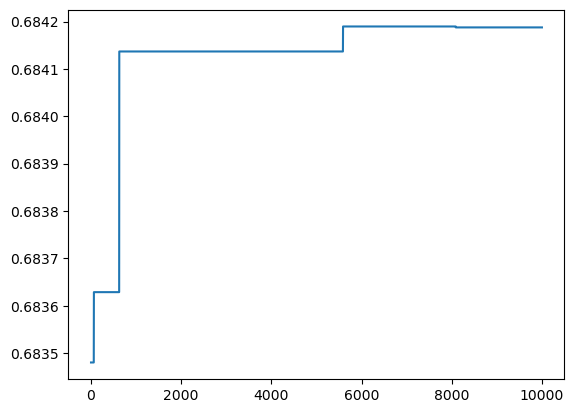

In [128]:
plt.plot(maximal_volume_record)

In [120]:
f'最终面积 / 最初面积 = {maximal_volume_record[-1] / maximal_volume_record[0]}'

'最终面积 / 最初面积 = 1.0020012147616308'

In [132]:
tvr.plot_volume(sofa, smoke_density_factor=5, camera_phi=45, camera_theta=30, init_taichi=False)

Text(0.5, 1.0, 'Trajectory of Movement')

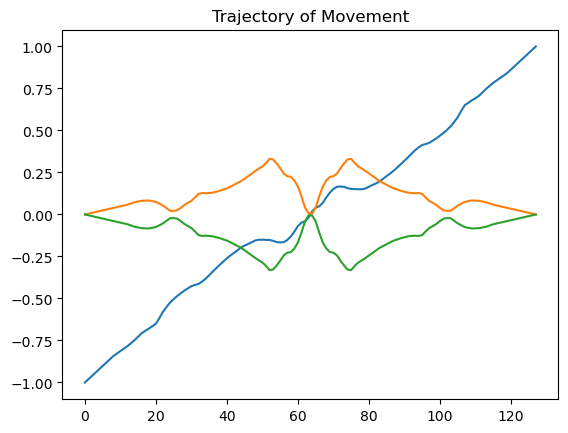

In [133]:
plt.plot(xs, markersize=2)
plt.plot(ys, markersize=2)
plt.plot(zs, markersize=2)
plt.title('Trajectory of Movement')

Text(0.5, 1.0, 'Trajectory of Rotation (Quaternion)')

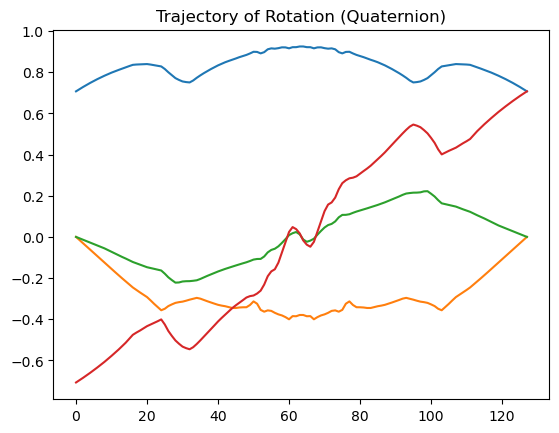

In [134]:
plt.plot(rotations[:, 0], markersize=2)
plt.plot(rotations[:, 1], markersize=2)
plt.plot(rotations[:, 2], markersize=2)
plt.plot(rotations[:, 3], markersize=2)
plt.title('Trajectory of Rotation (Quaternion)')

In [26]:
rotations[-2]

array([ 0.54443719,  0.17622829, -0.76184839, -0.30351074])

In [27]:
rotation_matrix = quaternion_to_rotation_matrix(rotations[-2])
rotation_matrix

array([[-0.34506348,  0.0619666 , -0.93653154],
       [-0.59900355,  0.75364965,  0.27056786],
       [ 0.7225828 ,  0.6543488 , -0.22293875]], dtype=float32)

In [28]:
rotation_matrix_to_quaternion(np.array([[0, 0, -1], [0, 1, 0], [1, 0, 0]], dtype=np.float32))

array([ 0.70710677,  0.        , -0.70710677,  0.        ], dtype=float32)